In [1]:
import os
os.chdir("/data/local/mvaquerizo/Classification/")

### Libraries

In [51]:
import sklearn as sk
import pandas as pd
import statistics as st
import numpy as np
from scripts.Funciones.Funciones import corr_loop, pca_plot, accuracy_models, prob_to_clase, performance_modelo, rendimiento_train, rendimiento_test
import scipy.stats as sc
import igraph as ig
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold, KFold, RepeatedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from multiprocessing import Pool
import pickle
import random
import gseapy as gp

In [264]:
import importlib
import scripts.Funciones.Funciones as f
importlib.reload(f)

<module 'scripts.Funciones.Funciones' from '/data/local/mvaquerizo/Classification/scripts/Funciones/Funciones.py'>

### Load data

In [3]:
data = pd.read_csv('data/conteos_normalizados_batch_E_R.csv', index_col=0)
data

,PIF_BI10,PIF_BI20,PIF_P37,PIF_P8,PIF_V56,PIF_B19,PIF_B28,PIF_BI14,PIF_P6,PIF_M8,...,ENC_R41,ENC_Bi10,ENC_R46,ENC_V16,ENC_B34,ENC_B35,ENC_B38,ENC_Bi21,ENC_V33,ENC_B12
WASH7P,1.416956,2.150675,2.410188,4.496283,2.137458,2.409733,3.688824,2.645052,2.032795,2.335017,...,1.281114,2.482424,1.946009,2.367969,1.084374,1.864328,0.998378,3.882634,2.179226,2.304804
LOC729737,2.486933,1.914562,0.957675,2.366079,-0.635290,3.912570,1.422141,2.881861,2.715712,1.538500,...,0.819952,1.923240,1.582823,2.397145,-0.300468,0.867535,1.772990,2.534721,2.386626,1.983932
OR4F3,2.506844,2.626319,1.792584,0.963817,3.725479,1.001411,1.483879,1.463692,2.781373,0.072682,...,0.306521,2.458734,0.289454,0.992456,-1.629756,1.270144,-0.239184,3.647641,3.308280,3.422612
LINC00115,2.627189,2.978013,2.950424,3.321384,1.879922,3.326740,2.356104,2.416914,3.113539,3.053060,...,1.228514,3.647642,1.943296,2.223973,1.960289,1.431430,1.744550,3.959604,3.922121,3.522578
LOC643837,3.426566,2.889866,3.172734,2.283649,2.775364,3.235707,2.512665,2.869325,3.126200,3.567046,...,3.733544,3.523876,3.984205,3.509307,3.441018,3.648065,3.780715,3.555065,2.993793,2.605577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FER1L4,1.298604,1.574143,1.818139,2.181592,1.154298,1.389565,2.248923,1.631111,1.464025,2.106421,...,0.361421,2.291553,1.147990,2.408343,0.328196,0.463799,0.073092,2.260956,2.721791,2.401736
HLA-B,7.538460,7.601285,5.590700,6.573674,6.109324,8.429804,8.405248,7.211955,6.224288,4.863674,...,6.347737,7.610228,6.386557,7.153547,7.372567,5.833219,7.010843,6.744905,5.615504,4.657256
MILR1,1.511858,0.718286,1.114791,0.730971,1.125609,1.240722,0.494125,0.971053,0.962772,-0.506271,...,1.141470,0.857004,0.650311,-1.073805,0.752226,0.858591,0.479263,0.821013,-0.419516,1.198850
SNORA19,4.872321,3.838647,4.949631,6.103236,5.524111,2.518479,1.632185,2.513953,3.329258,3.324792,...,4.429688,2.670759,2.607468,4.257273,3.364688,2.865633,3.013033,4.068920,3.207632,2.893268


In [4]:
ed = pd.read_csv('data/metadata_E_R.csv', index_col=0)
ed

,id_met,id_trans,age,bmi,outcome,p4_hours,TED,DV200,RIN,project,g_acc,estado_embrion,calidad_embrion,origen_ovocito,estado_ovocito,pgt,pub,ciclo
PIF_BI10,PAT_10,PIF_BI10,37,24.87,LB,130.200000,R2,71.87,5.9,PIF,R,Frozen,B,Own,Frozen,Euploid,False,Substituted
PIF_BI20,PAT_17,PIF_BI20,39,21.98,NB,117.333333,R1,81.99,3.1,PIF,R,Fresh,B,Donated,Frozen,NO_PGT,True,Substituted
PIF_P37,PAT_15,PIF_P37,38,20.70,LB,113.583333,PR,82.45,4.9,PIF,E,Frozen,B,Own,Fresh,Euploid,False,Substituted
PIF_P8,PAT_113,PIF_P8,36,21.38,NB,113.833333,PR,78.52,3.7,PIF,E,Fresh,A,Donated,Vitrified,NO_PGT,False,Substituted
PIF_V56,PAT_45,PIF_V56,48,26.08,NB,115.500000,PR,84.35,4.5,PIF,R,Fresh,B,Donated,Frozen,NO_PGT,False,Substituted
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENC_B35,PAT_60,ENC_B35,38,20.96,M,126.000000,PR-R1,81.98,8.6,ENC,R,Frozen,B,Own,Fresh,Euploid,False,Substituted
ENC_B38,PAT_77,ENC_B38,41,21.56,LB,126.833333,R2,85.68,9.1,ENC,E,Frozen,B,Own,Fresh,Euploid,False,Substituted
ENC_Bi21,PAT_103,ENC_Bi21,33,21.44,NB,123.833333,R2,85.23,8.4,ENC,E,Frozen,B,Own,Fresh,Euploid,False,Substituted
ENC_V33,PAT_153,ENC_V33,37,21.45,LB,109.250000,PR,85.50,8.7,ENC,E,Frozen,A,Own,Fresh,Euploid,True,HRT


### Clasificación
Separamos las muestras en envejecidas (E) y rejuvenecidas (R) en base a los datos epigenéticos

In [5]:
ed.index.tolist() == data.columns.tolist()

True

In [6]:
classification = pd.DataFrame({'sample': ed.index.tolist(), 
                              'class': list(ed.g_acc)},
                              index = ed.index.tolist())
classification

,sample,class
PIF_BI10,PIF_BI10,R
PIF_BI20,PIF_BI20,R
PIF_P37,PIF_P37,E
PIF_P8,PIF_P8,E
PIF_V56,PIF_V56,R
...,...,...
ENC_B35,ENC_B35,R
ENC_B38,ENC_B38,E
ENC_Bi21,ENC_Bi21,E
ENC_V33,ENC_V33,E


### Separación training - test
Para hacer la separación equiibrada cogemos el 70% de envejecidas y el 70% de rejuvenecidas para el training y el resto para el test.

In [ ]:
# Separamos envejecidas y rejuvenecidas
envejecidas = list(classification[classification['class'] == 'E'].index)
rejuvenecidas = list(classification[classification['class'] == 'R'].index)
len(envejecidas)
len(rejuvenecidas) 

In [ ]:
# Cogemos el 70% de cada grupo y lo añadimos a train
train = list()
train.extend(random.sample(envejecidas, k = round(len(envejecidas)*0.7)))
train.extend(random.sample(rejuvenecidas, k = round(len(rejuvenecidas)*0.7)))
train

In [ ]:
len(train)

In [ ]:
# Las muestras que no están en train son las que cogemos para el test
test = [x for x in classification.index if x not in train]
test

In [ ]:
len(test)

In [36]:
# Generamos el data y ed de train y test 
data_train = data.loc[:, train]
ed_train = ed.loc[train, :]
data_test = data.loc[:, test]
ed_test = ed.loc[test, :]
classification_train = classification.loc[train, :]

In [161]:
# Copiamos la info a csv para estudiar diferencias demográficas en R 
ed['group'] = 'test'
for i in range(0, ed.shape[0]): 
    if ed.index[i] in train: 
        ed.iloc[i, ed.shape[1]-1] = 'train'
ed
ed.to_csv('results2/train_test.csv', index=False)
# NO hay diferencias significativas entre train y test 

In [ ]:
# Guardamos el train y test en un archivo para usar siempre la misma separación de muestras
with open('results2/train_test.pickel', 'wb') as file: 
    pickle.dump(train, file)
    pickle.dump(test, file)

In [9]:
# Cargar train y test
with open('results/train_test.pickel', 'rb') as file:
    train = pickle.load(file)
    test = pickle.load(file)

data_train = data.loc[:, train]
ed_train = ed.loc[train, :]
data_test = data.loc[:, test]
ed_test = ed.loc[test, :]
classification_train = classification.loc[train, :]

### Selección de genes
Nos queremos quedar con aquellos genes correlacionados con la clase, pero que estén poco correlacionados entre sí para evitar colinealidad

In [ ]:
# Cálculo correlación gen - clase 
dat_c = data_train.loc[:, classification_train['sample']]
corr1 = pd.DataFrame()
for i in range(0,dat_c.shape[0]):
    res = sc.spearmanr(dat_c.iloc[i,:], classification_train.loc[:,'class'])
    res2 = pd.DataFrame.from_dict({'R': [res.statistic], 'p_value': [res.pvalue]})
    corr1 = pd.concat([corr1, res2])

In [ ]:
# Nos quedamos solo con aquellos genes con correlación positiva con la clase
corr1.index = dat_c.index
corr1['Genes'] = corr1.index
corr_genes = corr1[corr1['p_value']<=0.05].index.to_list()
subdat = data_train.loc[corr_genes, :]
subdat.shape

In [ ]:
# Calculamos la correlación gen a gen 
index_loop = []
for i in range(0,subdat.shape[0]):
    for j in range(i+1, subdat.shape[0]):
        index_loop.append((subdat,i,j))

with Pool() as pool:
    results = pool.map(corr_loop, index_loop)
corr2 = pd.concat(results)
corr2

In [ ]:
# Cogemos aquellos pares de genes altamente correlacionados entre ellos (R > 0.75) y generamos grafos de conectividad 
g = ig.Graph.TupleList(corr2[(corr2['p_value']<0.05) & (abs(corr2['R'])>0.75)].loc[:, ['Gene1', "Gene2"]].itertuples(index=False))
components = g.connected_components(mode='weak')
# Establecemos si están conectados entre sí o no
toselection = corr1.loc[g.get_vertex_dataframe()['name'],:]
toselection['membership'] = components.membership
len(toselection)

In [ ]:
# Seleccionamos los genes más conectados de cada grupo 
selected_genes = []
for i in set(toselection['membership']):
    values = toselection.loc[toselection['membership'] == i]
    selected_genes.append(values.iloc[pd.Series(abs(values['R']).tolist()).idxmax(), :].name)
len(selected_genes)

In [ ]:
# Al final nos quedamos con todos los genes correlacionados con la clase (R_clase < 0.05) 
# menos aquellos correlacionados entre ellos salvo los seleccionados 
remove_genes = [gene for gene in toselection.index.to_list() if gene not in selected_genes]
corr1_final = corr1.query('Genes not in @remove_genes and p_value < 0.05')
len(corr1_final.index)

In [ ]:
corr1_final['R_abs'] = abs(corr1_final.R)
corr1_final.sort_values('R_abs', ascending=False, inplace=True)
corr1_final

In [ ]:
# Guardamos los genes seleccionados 
with open('results2/corr1_final.pickel', 'wb') as file: 
    pickle.dump(corr1_final, file)

In [10]:
# Cargamos corr1_final
with open('results2/corr1_final.pickel', 'rb') as file: 
    corr1_final = pickle.load(file)

In [11]:
corr1_final

,R,p_value,Genes,R_abs
SUPT4H1,0.535294,0.000062,SUPT4H1,0.535294
GDI1,-0.504706,0.000186,GDI1,0.504706
PPP5C,-0.479679,0.000424,PPP5C,0.479679
C8orf31,-0.468556,0.000600,C8orf31,0.468556
TBL1XR1,0.454652,0.000910,TBL1XR1,0.454652
...,...,...,...,...
CCNA2,0.279465,0.049357,CCNA2,0.279465
TMEM150A,-0.279465,0.049357,TMEM150A,0.279465
CENPF,0.279465,0.049357,CENPF,0.279465
ZNF35,0.279465,0.049357,ZNF35,0.279465


In [12]:
data_filt = data_train.loc[corr1_final.index, :].T
data_filt

,SUPT4H1,GDI1,PPP5C,C8orf31,TBL1XR1,GMPPA,RNF31,DUOXA2,FBXO27,EIF2B1,...,TMED6,HIST1H4L,KAT2B,SERF1A,FGF10,CCNA2,TMEM150A,CENPF,ZNF35,ZNF816
ENC_B8,6.089738,7.288612,5.689508,0.236350,6.565826,6.114382,6.420756,1.709926,3.410931,5.135349,...,3.328201,3.893244,4.883424,5.783016,4.676829,2.796855,4.187024,3.865441,3.173641,4.621723
PIF_B30,5.899099,7.163058,5.940343,0.300231,6.175585,6.239248,6.416506,2.679011,3.060054,4.885286,...,4.244258,3.784101,4.991900,6.224320,5.656530,2.320154,3.561957,3.699334,3.219132,4.555670
ENC_V10,5.943904,7.320100,5.953442,1.087722,6.646024,5.721107,6.237299,0.404854,1.856719,5.116089,...,1.590271,3.328366,4.720427,5.752136,5.623227,1.747107,3.995749,3.662586,2.826964,4.583087
PIF_P37,5.631297,7.634182,6.084325,1.622884,5.953162,6.354717,7.047706,2.501873,2.080965,4.906708,...,1.793641,2.305251,4.744778,5.270872,5.578837,2.084643,3.844520,3.774461,3.231031,6.131820
PIF_V26,5.945344,7.624320,6.115134,2.496419,6.304405,6.112113,6.717909,-0.212478,3.021941,4.840887,...,-0.622578,2.841380,4.361284,6.263730,5.636746,2.526614,3.997169,3.690915,3.437606,4.813613
ENC_B3,5.876339,6.971978,6.061974,1.881986,6.766641,5.787345,6.276392,2.250675,2.666163,5.183958,...,2.532081,3.437621,4.784140,6.178883,5.256040,2.691214,3.622236,3.616965,3.514222,5.114321
PIF_V55,5.745355,7.290476,5.968727,0.235062,6.454510,5.852695,6.509235,1.280091,2.064003,4.837387,...,0.863344,2.041988,4.985119,5.302039,5.167089,2.293928,3.793581,3.416140,2.394701,5.397033
ENC_R34,6.059129,7.123665,5.999757,1.127801,6.723221,5.993115,6.478690,1.380011,1.934449,5.024142,...,3.032856,3.229138,4.543017,6.184482,5.665248,1.836070,3.822904,3.766880,3.504457,4.880565
PIF_V65,6.183155,7.367314,6.000224,-1.305485,6.234566,5.789549,6.426969,0.275017,3.128945,4.791227,...,3.477690,3.311580,5.392887,5.560045,4.288551,2.525546,4.129412,4.574581,3.554374,5.154620
PIF_P48,5.920473,7.560724,5.807448,0.393455,6.623683,6.014672,6.574260,2.067554,2.370488,4.928179,...,0.106710,3.251687,5.403036,5.900920,5.301958,1.832116,4.310157,3.353892,3.341389,4.926223


In [ ]:
# Mezclamos las muestras para que no estén separadas E y R 
sample = list(data_filt.index)
random.shuffle(sample)
data_filt = data_filt.loc[sample, :]
ed_filt = ed_train.loc[sample, :]

In [ ]:
ed_filt.index.to_list() == data_filt.index.to_list()

In [ ]:
y = list(ed_filt.g_acc)
y

In [ ]:
# Guardamos los datos 
with open('results2/datos_filtrados.pickel', 'wb') as file: 
    pickle.dump(data_filt, file)
    pickle.dump(ed_filt, file)
    pickle.dump(y, file)

In [13]:
# Cargar los datos
with open('results2/datos_filtrados.pickel', 'rb') as file:
    data_filt = pickle.load(file)
    ed_filt = pickle.load(file)
    y = pickle.load(file)

### Cross-validation
Generamos la separación de las muestras del train original en train-test para el entrenamiento y validación interna de los modelos. Tenemos que generar en total la división train-test 5 fold 10 veces, por lo que al final tenemos 50 conjuntos de datos

In [ ]:
# Vamos generando las divisones y guardamos los índices de las muestras en un diccionario de diccionarios.
kf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=123)

cross_val = {}
aux = {}
time = 1
fold = 1

for train, test in kf.split(data_filt):
    aux[fold] = {'Train': train, 'Test': test}
    if fold < 5: 
        fold += 1
    else: 
        cross_val[time] = aux
        aux = {}
        fold = 1
        time += 1
    
cross_val	

In [ ]:
# Guardamos el cross_val en un archivo para usar siempre la misma separación de muestras
with open('results2/cross_val.pickel', 'wb') as file: 
    pickle.dump(cross_val, file)

In [53]:
# Cargar el cross validation
with open('results2/cross_val.pickel', 'rb') as file:
    cross_val = pickle.load(file)

In [260]:
results = []

n_genes = (list(range(1, 51)) +
           list(range(55, 101, 5)) +
           list(range(110, 201, 10)) +
           list(range(220, data_filt.shape[1] + 1, 20)) +
           [data_filt.shape[1]]
          )
                   
n_genes = sorted(set(n_genes))

for i in n_genes:
    print(i)
    sel_genes = corr1_final.iloc[:i, :]['Genes'].to_list()
    sel_data = data_filt.loc[:, sel_genes]

    acc_svm, acc_rf, acc_knn = accuracy_models(cross_val, sel_data, y)

    results.append({'genes': i, 'SVM': acc_svm, 'Rf': acc_rf, 'kNN': acc_knn})

accuracy = pd.DataFrame(results)
accuracy

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
55
60
65
70
75
80
85
90
95
100
110
120
130
140
150
160
170
180
190
200
220
240
260
280
300
320
340
360
380
400
420
428


,genes,SVM,Rf,kNN
0,1,0.744,0.658,0.754
1,2,0.684,0.724,0.672
2,3,0.716,0.790,0.728
3,4,0.708,0.788,0.728
4,5,0.736,0.768,0.738
...,...,...,...,...
77,360,0.848,0.724,0.804
78,380,0.850,0.738,0.824
79,400,0.840,0.720,0.786
80,420,0.842,0.730,0.772


In [ ]:
# Guardamos la información de accuracy en un csv 
accuracy.to_csv('results2/accuracy2.csv', index=False)

In [14]:
accuracy = pd.read_csv('results2/accuracy.csv', index_col=0)
n_genes = (list(range(1, 51)) +
           list(range(55, 101, 5)) +
           list(range(110, 201, 10)) +
           list(range(220, data_filt.shape[1] + 1, 20)) +
           [data_filt.shape[1]]
          )
                   
n_genes = sorted(set(n_genes))

In [18]:
accuracy.columns = ['SVM', 'RF', 'kNN']
accuracy

,SVM,RF,kNN
genes,,,
1,0.744,0.658,0.754
2,0.684,0.724,0.672
3,0.716,0.790,0.728
4,0.708,0.788,0.728
5,0.736,0.768,0.738
...,...,...,...
360,0.848,0.724,0.804
380,0.850,0.738,0.824
400,0.840,0.720,0.786


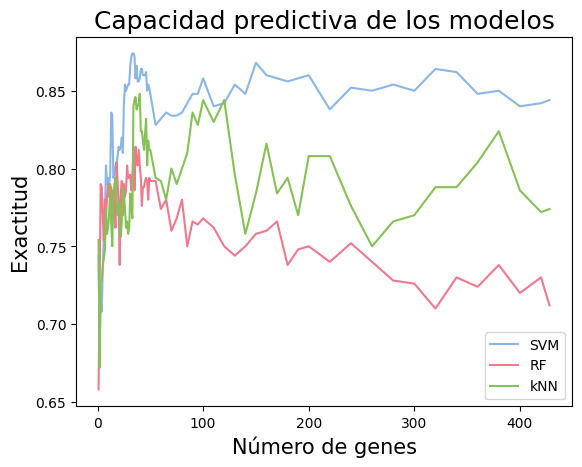

In [25]:
fig, ax = plt.subplots()
plt.plot(n_genes, accuracy.SVM, color = '#8AB6E9')
plt.plot(n_genes, accuracy.RF, color = '#F1788D')
plt.plot(n_genes, accuracy.kNN, color = '#86C157')
plt.legend(['SVM', 'RF', 'kNN'])
plt.xlabel('Número de genes', size = 15)
plt.ylabel('Exactitud', size = 15)
plt.title('Capacidad predictiva de los modelos', size = 18)
plt.show()
fig.savefig('results2/plot_precision.jpg', dpi=500)
plt.close(fig)

In [30]:
# Sacamos el número de genes y modelo que obtiene el mayor accuracy
n = accuracy.stack().idxmax()[0]
n

np.int64(33)

In [31]:
# Sacamos los df de train y test con los genes seleccionados 
sel_genes = corr1_final.iloc[:n, :]['Genes'].to_list()
sel_data_train = data_filt.loc[:, sel_genes]
sel_ed_train = ed_filt.loc[sel_data_train.index, :]
sel_data_test = data_test.T.loc[:, sel_genes]
sel_ed_test = ed_test.loc[sel_data_test.index, :]

In [49]:
# Guardamos el listado de genes en un fichero de texto
with open("results2/firma_transcriptomica.txt", "w") as f:
    for item in sel_genes:
        f.write(str(item) + "\n")

### PCA 
Hacemos PCA con el total de genes (13.281), con la primera selección en base a la correlación (618) y con el número final.

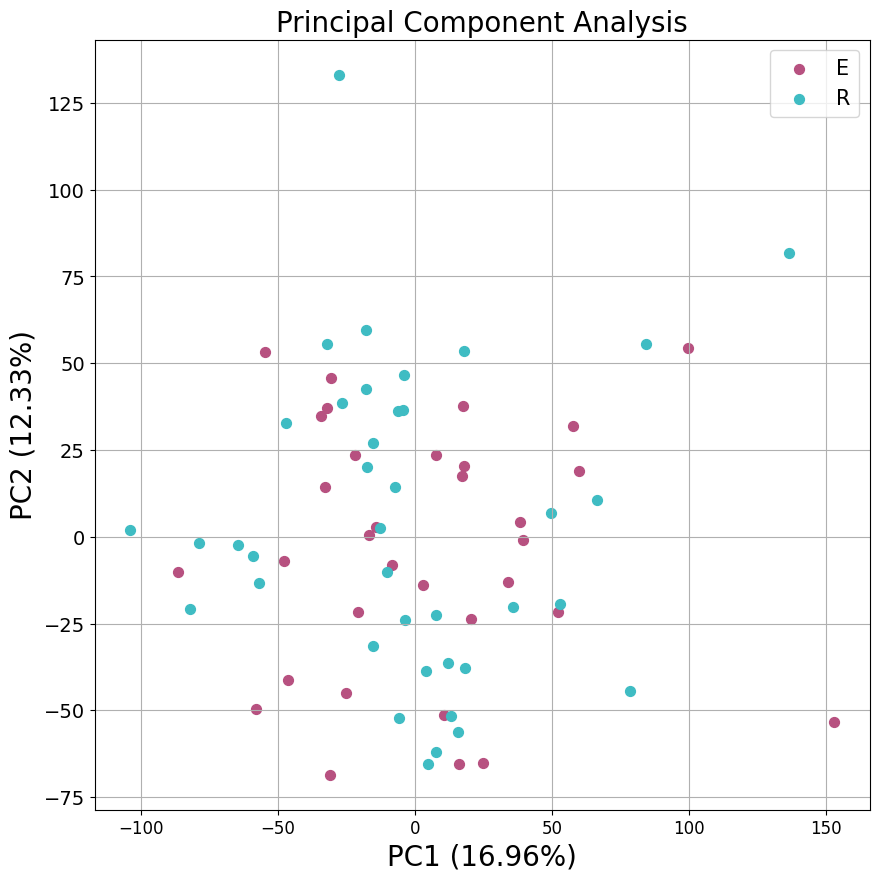

In [54]:
# Todos los genes
pca_plot(data.T, list(ed.g_acc))

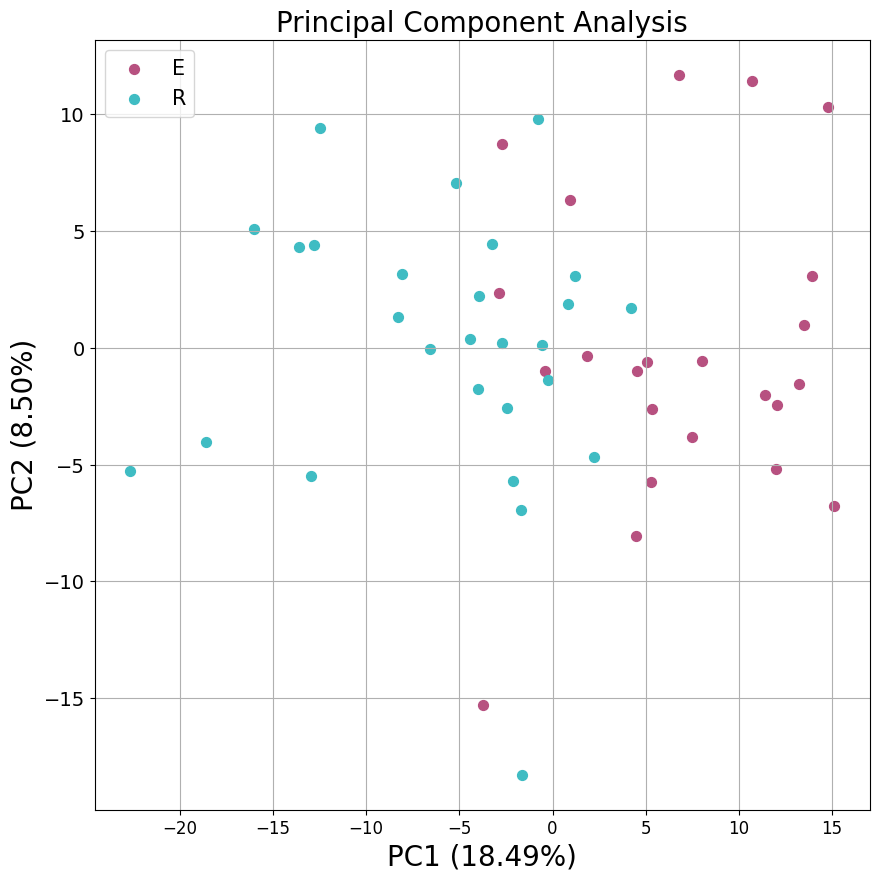

In [55]:
# Selección de genes tras correlación (618)
pca_plot(data_filt, list(ed_filt.g_acc))

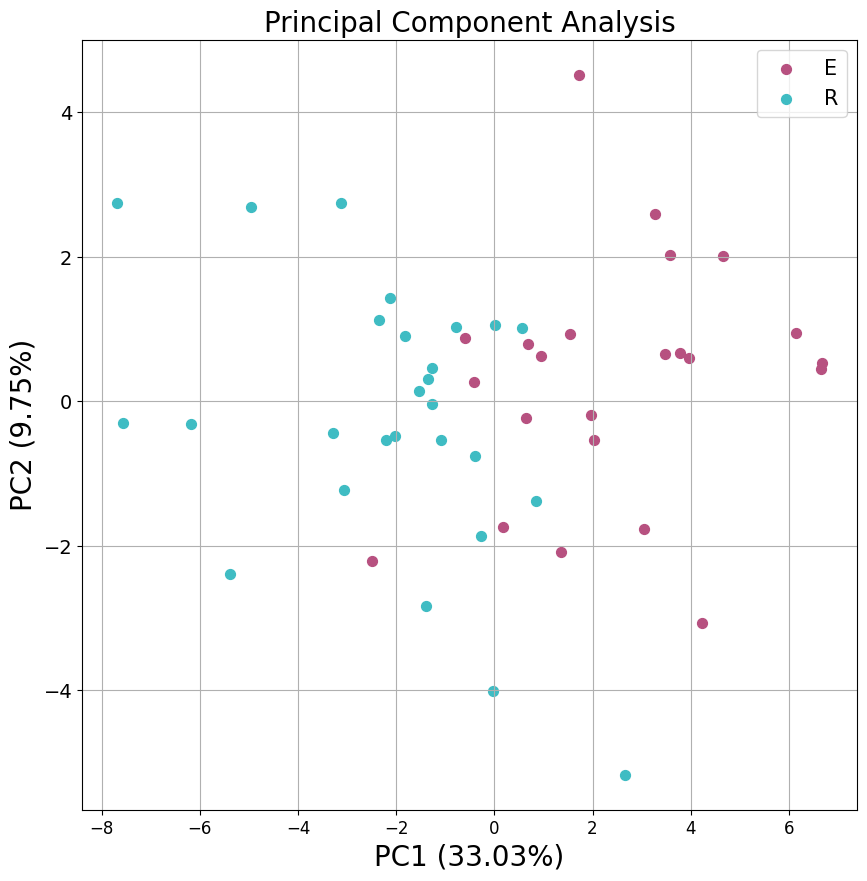

In [ ]:
# Firma de genes (33)
pca_plot(sel_data_train, list(sel_ed_train.g_acc))

In [ ]:
# Todos los genes en el test
pca_plot(data_test.T, list(ed_test.g_acc))

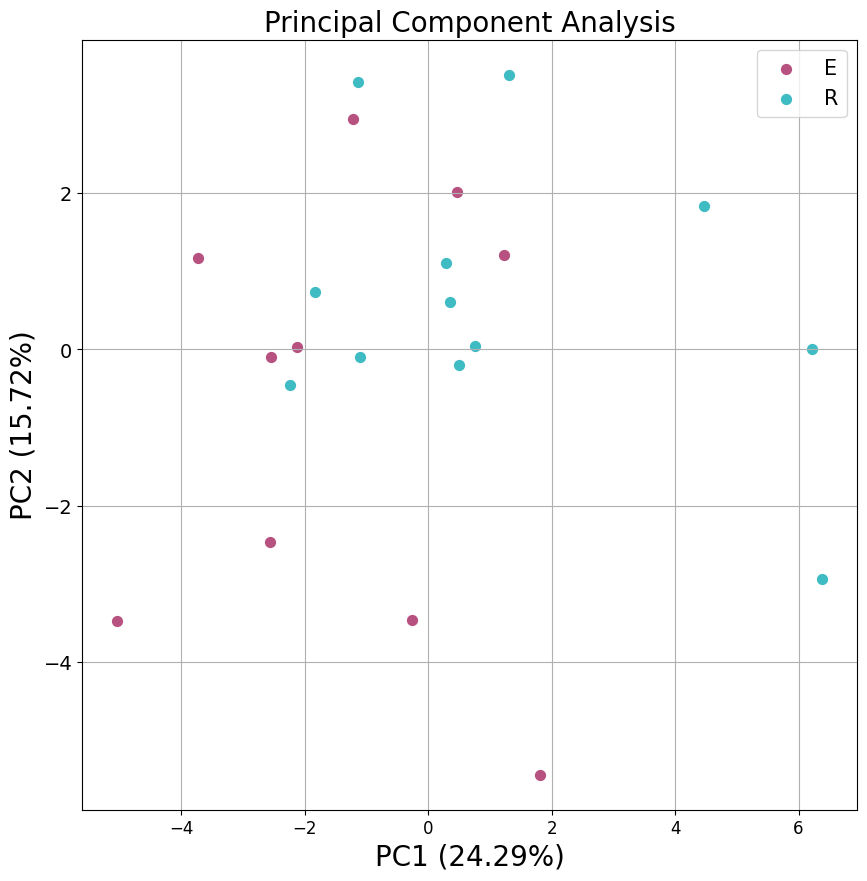

In [ ]:
# Firma de genes (33) y test 
pca_plot(sel_data_test, list(sel_ed_test.g_acc))

### Caracterización funcional de la firma 

In [48]:
enr = gp.enrichr(
    gene_list = sel_genes,
    gene_sets = ['GO_Biological_Process_2021',
               'KEGG_2021_Human',
               'Reactome_2022'],
    organism = 'Human'
)

results = enr.results
results

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,Reactome_2022,Heme Signaling R-HSA-9707616,3/45,0.000055,0.009195,0,0,47.440476,464.968148,CRTC2;TBL1XR1;CLOCK
1,Reactome_2022,Circadian Clock R-HSA-400253,3/69,0.000199,0.016524,0,0,30.153030,256.957700,CRTC2;TBL1XR1;CLOCK
2,Reactome_2022,"BMAL1:CLOCK,NPAS2 Activates Circadian Gene Exp...",2/27,0.000903,0.038237,0,0,51.463226,360.743837,TBL1XR1;CLOCK
3,Reactome_2022,Cellular Responses To Stress R-HSA-2262752,6/722,0.001043,0.038237,0,0,5.974860,41.021717,ACADVL;CRTC2;TBL1XR1;CYBB;P4HB;CLOCK
4,Reactome_2022,Cellular Responses To Stimuli R-HSA-8953897,6/736,0.001152,0.038237,0,0,5.856012,39.624721,ACADVL;CRTC2;TBL1XR1;CYBB;P4HB;CLOCK
...,...,...,...,...,...,...,...,...,...,...
493,KEGG_2021_Human,"Signaling By Rho GTPases, Miro GTPases And RHO...",1/660,0.669871,0.685628,0,0,0.915592,0.366850,CYBB
494,KEGG_2021_Human,Metabolism Of RNA R-HSA-8953854,1/666,0.673237,0.685628,0,0,0.907049,0.358881,RCL1
495,KEGG_2021_Human,Cytokine Signaling In Immune System R-HSA-1280215,1/702,0.692744,0.699052,0,0,0.858862,0.315283,P4HB
496,KEGG_2021_Human,Transport Of Small Molecules R-HSA-382551,1/706,0.694841,0.699052,0,0,0.853812,0.310850,P4HB


In [43]:
gp.get_library_name()

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CM4AI_U2OS_Protein_Localization_Assemblies',
 'COMPARTMENTS_Curated_2025',
 'COMPARTMENTS_Experimental_2025',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'Carcinogenome',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'ClinVar_2025',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popul

### Rendimiento del modelo con firma génica en train (CV)

In [54]:
accuracy, sensibilidad, especificidad, F1_score = rendimiento_train(cross_val, sel_data_train, list(sel_ed_train.g_acc))
performance = {'accuracy': np.mean(pd.DataFrame(accuracy), axis = 0).tolist(),
               'sensibilidad': np.mean(pd.DataFrame(sensibilidad), axis = 0).tolist(),
               'especificidad': np.mean(pd.DataFrame(especificidad), axis = 0).tolist(), 
               'F1_score': np.mean(pd.DataFrame(F1_score), axis = 0).tolist()}
performance = pd.DataFrame(performance).T
performance.columns = pd.DataFrame(accuracy).columns
performance

,SVM,Rf,kNN,SVM_Rf,SVM_kNN,Rf_kNN,Prob_media,Votos
accuracy,0.87400,0.79200,0.76800,0.87600,0.84800,0.79200,0.83200,0.83400
sensibilidad,0.89640,0.70948,0.62524,0.85658,0.78772,0.67932,0.75400,0.74536
especificidad,0.84166,0.89000,0.91464,0.88528,0.89366,0.90490,0.90364,0.92486
F1_score,0.84698,0.74256,0.67972,0.84974,0.80034,0.71734,0.77246,0.79200


### Rendimiento del modelo con firma génica en test

In [55]:
performance_test, probabilities_test = rendimiento_test(sel_data_train, sel_ed_train, sel_data_test, sel_ed_test)
performance_test

,SVM,Rf,kNN,Prob_media,SVM_Rf,SVM_kNN,Rf_kNN,Votos
Acc,0.682,0.864,0.727,0.727,0.773,0.682,0.818,0.773
Sens,0.700,0.800,0.600,0.600,0.700,0.600,0.600,0.700
Spec,0.667,0.917,0.833,0.833,0.833,0.750,1.000,0.833
F1,0.667,0.842,0.667,0.667,0.737,0.632,0.750,0.737


In [ ]:
# Guardamos los resultados
with open('results2/performance.pickel', 'wb') as file: 
    pickle.dump(probabilities, file)
    pickle.dump(prediction, file)
    pickle.dump(performance, file)

pd.DataFrame(probabilities).to_csv('results2/probabilidades.csv', index=False)
pd.DataFrame(prediction).to_csv('results2/predicciones.csv', index=False)
pd.DataFrame(performance).to_csv('results2/rendimiento.csv', index=False)


### Curvas ROC

In [263]:
model_svm = svm.SVC(random_state=123, probability=True)
model_svm.fit(data_train, y_train)
prob_svm = model_svm.predict_proba(data_test)[:, idx].tolist()
prob_svm
#lb = LabelBinarizer()
#y_bin = lb.fit_transform(y).ravel()





NameError: name 'y_train' is not defined

In [291]:
probabilities_test.loc[:, 'TL'] =  sel_ed_test.loc[:, 'g_acc']